# Multi-Disease Lung Pathology Detection from Chest X-Rays
## Using Deep Learning and Explainable AI
### Notebook 2 - Data Preprocessing & Augmentation Pipeline

---

**Dataset:** CheXpert v1.0-small — Stanford University ML Group  
**Reference:** Irvin et al. (2019). *CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison.* AAAI. https://doi.org/10.1609/aaai.v33i01.3301590

---

## Context

Exploratory Data Analysis (Notebook 1) established the following characteristics of the CheXpert dataset that directly inform this preprocessing pipeline:

| Finding from EDA | Preprocessing Decision |
|---|---|
| 191,027 frontal + 32,387 lateral views | **Keep frontal views only** — consistent anatomy, standard for benchmarks |
| Labels encoded as `1.0 / 0.0 / -1.0 / NaN` | **U-Zeros strategy** — map `-1.0 → 0.0`, `NaN → 0.0` |
| Variable image resolution (mean ~390×320 px) | **Resize all images to 224×224 px** — required by ImageNet pre-trained models |
| Severe class imbalance (e.g. Pneumonia ≪ Pleural Effusion) | **Weighted Binary Cross-Entropy loss** + per-label class weights |
| Multi-label problem (patient can have multiple conditions) | **Sigmoid output** (not Softmax) — independent probability per label |

## Objectives

1. Filter and clean the training metadata
2. Apply the U-Zeros uncertainty label strategy
3. Build an efficient `tf.data` image loading pipeline
4. Implement data augmentation for training
5. Compute per-label class weights
6. Verify the pipeline with batch statistics and visual samples
7. Save processed metadata CSVs for use in training notebooks

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/CheXpert_Project/outputs', exist_ok=True)
print('Drive mounted.')
print('train.csv exists:', os.path.exists('/content/drive/MyDrive/CheXpert_Project/data/train.csv'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
train.csv exists: True


---
## 1. Environment Setup

In [ ]:
import os, warnings, random
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'DejaVu Sans'

print('TensorFlow version :', tf.__version__)
print('GPU available      :', len(tf.config.list_physical_devices('GPU')) > 0)
for gpu in tf.config.list_physical_devices('GPU'):
    print(' └─', gpu)

TensorFlow version : 2.20.0
GPU available      : True
 └─ PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


---
## 2. Configuration Constants

All hyperparameters and paths are defined here. Changing a value in this cell propagates through the entire notebook.

In [ ]:
# ─── Paths ───────────────────────────────────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/CheXpert_Project/data"
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
VALID_CSV = os.path.join(BASE_PATH, "valid.csv")
OUT_DIR   = "/content/drive/MyDrive/CheXpert_Project/outputs"

# ─── Image parameters ────────────────────────────────────────────────────────
IMG_SIZE    = 224          # target resolution (224×224) — ImageNet standard
CHANNELS    = 3            # replicate grayscale to 3 channels for ImageNet weights
BATCH_SIZE  = 32

# ─── Dataset split ratios ────────────────────────────────────────────────────
VAL_SPLIT   = 0.10         # 10% of frontal training set → internal validation
TEST_SPLIT  = 0.10         # 10% of frontal training set → held-out test set
# Remaining 80% → training

# ─── Label columns ───────────────────────────────────────────────────────────
LABEL_COLS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]
NUM_CLASSES = len(LABEL_COLS)

print(f'Image size   : {IMG_SIZE}×{IMG_SIZE}×{CHANNELS}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Splits       : train={1-VAL_SPLIT-TEST_SPLIT:.0%} | val={VAL_SPLIT:.0%} | test={TEST_SPLIT:.0%}')
print(f'Num classes  : {NUM_CLASSES}')

Image size   : 224×224×3
Batch size   : 32
Splits       : train=80% | val=10% | test=10%
Num classes  : 14


---
## 3. Load & Filter Metadata

Based on the EDA findings, only **frontal-view** studies are retained. Lateral views are excluded to reduce anatomical variability and maintain consistency with the CheXNet benchmark (Rajpurkar et al., 2017).

In [ ]:
train_raw = pd.read_csv(TRAIN_CSV)
valid_raw = pd.read_csv(VALID_CSV)

print(f'Raw training rows      : {len(train_raw):,}')
print(f'Raw validation rows    : {len(valid_raw):,}')

# ─── Keep frontal views only ─────────────────────────────────────────────────
train_frontal = train_raw[train_raw['Frontal/Lateral'] == 'Frontal'].copy()
valid_frontal = valid_raw.copy()   # validation set is already all frontal

print(f'\nFrontal training rows  : {len(train_frontal):,}')
print(f'Lateral rows excluded  : {len(train_raw) - len(train_frontal):,}')
print(f'Validation rows        : {len(valid_frontal):,} (all frontal, gold-standard)')

Raw training rows      : 223,414
Raw validation rows    : 234

Frontal training rows  : 191,027
Lateral rows excluded  : 32,387
Validation rows        : 234 (all frontal, gold-standard)


In [ ]:
# ─── Filter to patients that exist in Drive ──────────────────────────────────
# The Drive copy contains 31,721 of the ~64,000 CheXpert patients.
# Rows referencing missing patients are dropped before any further processing.

import os

train_dir = os.path.join(BASE_PATH, 'train')
existing_patients = set(os.listdir(train_dir))

def get_patient_id(path):
    parts = path.replace('CheXpert-v1.0-small/', '').split('/')
    return parts[1] if len(parts) > 1 else ''

train_frontal['patient'] = train_frontal['Path'].apply(get_patient_id)
n_before = len(train_frontal)
train_frontal = train_frontal[train_frontal['patient'].isin(existing_patients)].copy()
train_frontal = train_frontal.drop(columns=['patient']).reset_index(drop=True)

print(f'Patients available in Drive : {len(existing_patients):,}')
print(f'Frontal rows before filter  : {n_before:,}')
print(f'Frontal rows after filter   : {len(train_frontal):,}')
print(f'Rows dropped                : {n_before - len(train_frontal):,}')

Patients available in Drive : 31,721
Frontal rows before filter  : 191,027
Frontal rows after filter   : 104,816
Rows dropped                : 86,211


---
## 4. Uncertainty Label Strategy: U-Zeros

CheXpert contains three types of non-positive entries for each label:
- `NaN` — the label was not mentioned in the radiology report
- `0.0` — explicitly labelled as absent
- `-1.0` — labelled as **uncertain**

**U-Zeros strategy:** Both `NaN` and `-1.0` are mapped to `0.0` (negative). This is the conservative approach used in the original CheXpert paper as the primary baseline. It minimises false positive predictions at the cost of potentially missing some true uncertain cases.

> Alternative strategy (U-Ones) maps `-1.0 → 1.0` and will be evaluated in the ablation study in Notebook 4.

In [ ]:
def apply_u_zeros(df, label_cols):
    """
    Apply the U-Zeros uncertainty handling strategy.
    Maps NaN → 0.0 and -1.0 → 0.0 for all label columns.
    Positive labels (1.0) are unchanged.

    Parameters
    ----------
    df         : pd.DataFrame — metadata dataframe
    label_cols : list[str]   — list of pathology label column names

    Returns
    -------
    pd.DataFrame with cleaned binary labels (0.0 or 1.0 only)
    """
    df = df.copy()
    for col in label_cols:
        df[col] = df[col].fillna(0.0)          # NaN → 0
        df[col] = df[col].replace(-1.0, 0.0)   # uncertain → 0
        df[col] = df[col].astype(np.float32)
    return df

train_clean = apply_u_zeros(train_frontal, LABEL_COLS)
valid_clean = apply_u_zeros(valid_frontal, LABEL_COLS)

# Verify: no -1.0 or NaN remain
for col in LABEL_COLS:
    assert (train_clean[col] == -1.0).sum() == 0, f'Uncertain labels remain in {col}'
    assert train_clean[col].isna().sum() == 0,    f'NaN labels remain in {col}'

# Unique values after cleaning
sample_vals = {col: sorted(train_clean[col].unique().tolist()) for col in LABEL_COLS[:4]}
print('Label values after U-Zeros (sample of 4 columns):')
for k, v in sample_vals.items():
    print(f'  {k:<35}: {v}')
print('\nAll assertions passed — labels are binary (0.0 / 1.0) only.')

Label values after U-Zeros (sample of 4 columns):
  No Finding                         : [0.0, 1.0]
  Enlarged Cardiomediastinum         : [0.0, 1.0]
  Cardiomegaly                       : [0.0, 1.0]
  Lung Opacity                       : [0.0, 1.0]

All assertions passed — labels are binary (0.0 / 1.0) only.


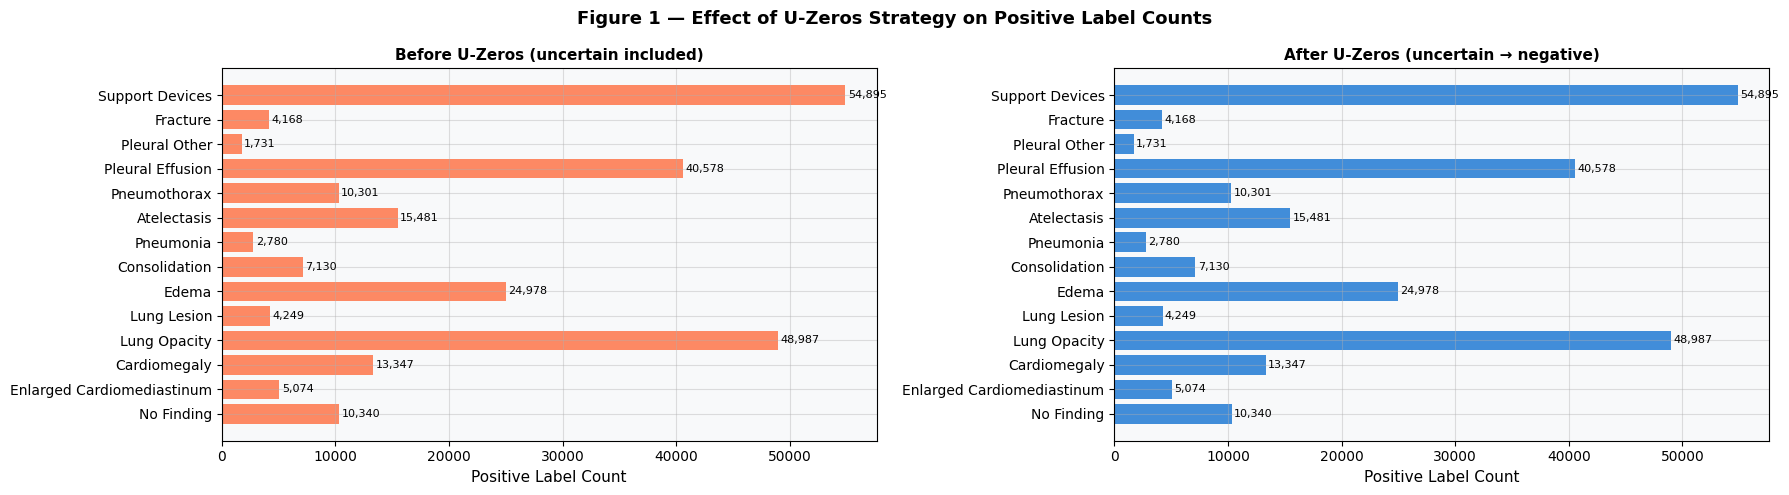

In [ ]:
# ─── Figure 1: Label distribution before vs after U-Zeros ───────────────────
before_pos = [(train_frontal[c] == 1.0).sum() for c in LABEL_COLS]
after_pos  = [(train_clean[c]   == 1.0).sum() for c in LABEL_COLS]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Figure 1 — Effect of U-Zeros Strategy on Positive Label Counts',
             fontsize=13, fontweight='bold')

for ax, vals, title, color in zip(
    axes,
    [before_pos, after_pos],
    ['Before U-Zeros (uncertain included)', 'After U-Zeros (uncertain → negative)'],
    ['#FF7043', '#1976D2']
):
    ax.barh(LABEL_COLS, vals, color=color, alpha=0.82)
    ax.set_xlabel('Positive Label Count', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v + 200, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb2_01_uzeros_effect.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Build Image Paths

CheXpert CSV paths use the prefix `CheXpert-v1.0-small/` which must be stripped and replaced with the Kaggle base path.

In [ ]:
def build_full_path(df, base=BASE_PATH):
    """
    Replace the 'CheXpert-v1.0-small/' prefix in the Path column
    with the actual Kaggle dataset base path.
    """
    df = df.copy()
    df['full_path'] = df['Path'].str.replace(
        'CheXpert-v1.0-small/', '', regex=False
    ).apply(lambda p: os.path.join(base, p))
    return df

train_clean = build_full_path(train_clean)
valid_clean = build_full_path(valid_clean)

# Spot-check: verify a sample image is accessible
sample_path = train_clean['full_path'].iloc[0]
img_check   = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
assert img_check is not None, f'Cannot read image: {sample_path}'
print(f'Path check passed.')
print(f'  Sample path   : {sample_path}')
print(f'  Image shape   : {img_check.shape}')

Path check passed.
  Sample path   : /content/drive/MyDrive/CheXpert_Project/data/train/patient00001/study1/view1_frontal.jpg
  Image shape   : (320, 389)


---
## 6. Train / Validation / Test Split

The 191,027 frontal training studies are split into three non-overlapping sets:

| Split | Ratio | Purpose |
|-------|-------|--------|
| **Train** | 80% | Model parameter optimisation |
| **Validation** | 10% | Hyperparameter tuning, early stopping |
| **Test** | 10% | Final held-out evaluation (not touched during training) |

The official CheXpert validation set (N=234, radiologist-annotated) is used separately as the **gold-standard evaluation set** for AUC-ROC comparison.

In [ ]:
# ─── Stratified 80/10/10 split ──────────────────────────────────────────────
# Stratify on Pleural Effusion — the most frequent label, ensuring balanced splits.
stratify_col = 'Pleural Effusion'

train_df, temp_df = train_test_split(
    train_clean, test_size=0.20,
    random_state=SEED, stratify=train_clean[stratify_col]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    random_state=SEED, stratify=temp_df[stratify_col]
)

print('=' * 55)
print('  Dataset Split Summary')
print('=' * 55)
print(f'  Available studies  : {len(train_clean):,}  (filtered to Drive patients)')
print(f'  Training set       : {len(train_df):,}  (80%)')
print(f'  Validation set     : {len(val_df):,}  (10%)')
print(f'  Test set           : {len(test_df):,}  (10%)')
print(f'  Gold standard      : {len(valid_clean):,}  (CheXpert official val set)')
print('=' * 55)

assert len(set(train_df['full_path']) & set(val_df['full_path']))  == 0
assert len(set(train_df['full_path']) & set(test_df['full_path'])) == 0
assert len(set(val_df['full_path'])   & set(test_df['full_path'])) == 0
print('No overlap between splits confirmed.')

  Dataset Split Summary
  Available studies  : 104,816  (filtered to Drive patients)
  Training set       : 83,852  (80%)
  Validation set     : 10,482  (10%)
  Test set           : 10,482  (10%)
  Gold standard      : 234  (CheXpert official val set)
No overlap between splits confirmed.


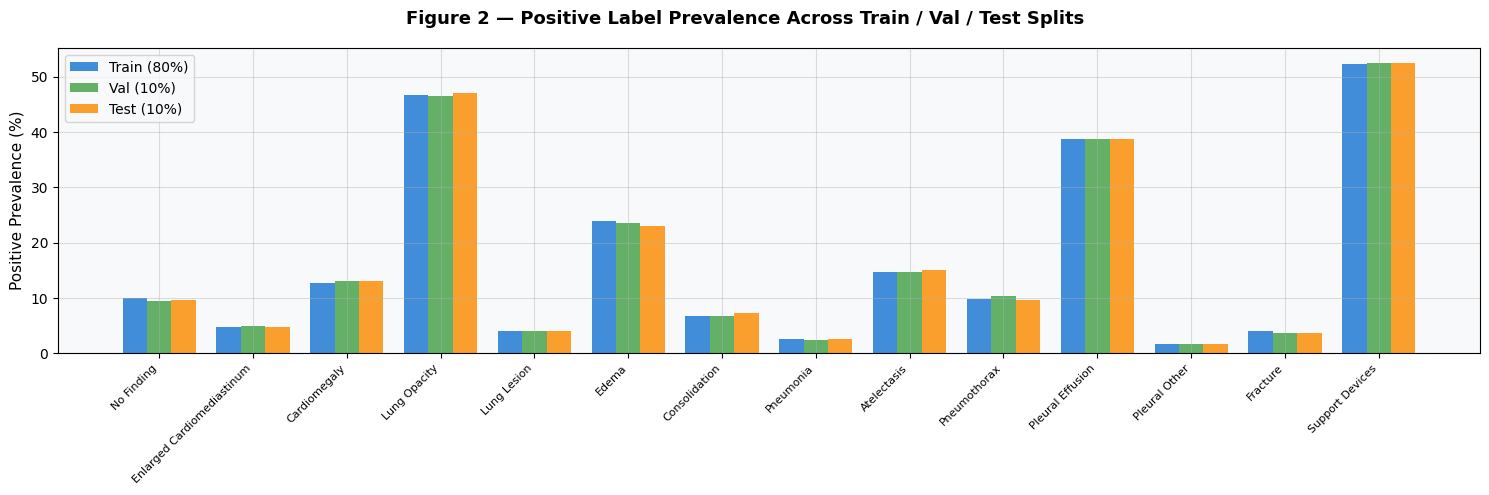

In [ ]:
# ─── Figure 2: Label prevalence consistency across splits ───────────────────
fig, ax = plt.subplots(figsize=(15, 5))
fig.suptitle('Figure 2 — Positive Label Prevalence Across Train / Val / Test Splits',
             fontsize=13, fontweight='bold')

x     = np.arange(NUM_CLASSES)
width = 0.26
for i, (df, label, color) in enumerate([
    (train_df, 'Train (80%)',      '#1976D2'),
    (val_df,   'Val (10%)',        '#43A047'),
    (test_df,  'Test (10%)',       '#FB8C00'),
]):
    pcts = [df[c].mean() * 100 for c in LABEL_COLS]
    ax.bar(x + i * width, pcts, width, label=label, color=color, alpha=0.82)

ax.set_xticks(x + width)
ax.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Positive Prevalence (%)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb2_02_split_consistency.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Class Weights for Imbalanced Labels

Several pathologies are rare (e.g. Pneumonia, Lung Lesion, Fracture). Without correction, the model would learn to predict the majority class and still achieve high accuracy. Per-label class weights are computed and passed to the loss function during training.

In [ ]:
def compute_label_weights(df, label_cols):
    """
    Compute positive class weights for each label using the
    inverse frequency formula:
        w_pos = (N - N_pos) / N_pos
    where N is total samples and N_pos is positive count.
    This is equivalent to sklearn's 'balanced' class weight for binary labels.
    """
    N = len(df)
    weights = {}
    for col in label_cols:
        n_pos = df[col].sum()
        n_neg = N - n_pos
        w_pos = n_neg / n_pos if n_pos > 0 else 1.0
        weights[col] = round(float(w_pos), 4)
    return weights

class_weights = compute_label_weights(train_df, LABEL_COLS)

print(f'{"Pathology":<35}  {"Pos count":>10}  {"Weight (w_pos)":>15}')
print('-' * 65)
for col in LABEL_COLS:
    n_pos = int(train_df[col].sum())
    w     = class_weights[col]
    bar   = '█' * min(int(w / 3), 20)
    print(f'{col:<35}  {n_pos:>10,}  {w:>12.2f}x  {bar}')

print('\nHighest weight → most imbalanced label → receives largest gradient boost during training.')

Pathology                             Pos count   Weight (w_pos)
-----------------------------------------------------------------
No Finding                                8,327          9.07x  ███
Enlarged Cardiomediastinum                4,052         19.69x  ██████
Cardiomegaly                             10,604          6.91x  ██
Lung Opacity                             39,180          1.14x  
Lung Lesion                               3,401         23.66x  ███████
Edema                                    20,090          3.17x  █
Consolidation                             5,662         13.81x  ████
Pneumonia                                 2,250         36.27x  ████████████
Atelectasis                              12,361          5.78x  █
Pneumothorax                              8,202          9.22x  ███
Pleural Effusion                         32,462          1.58x  
Pleural Other                             1,382         59.67x  ███████████████████
Fracture                       

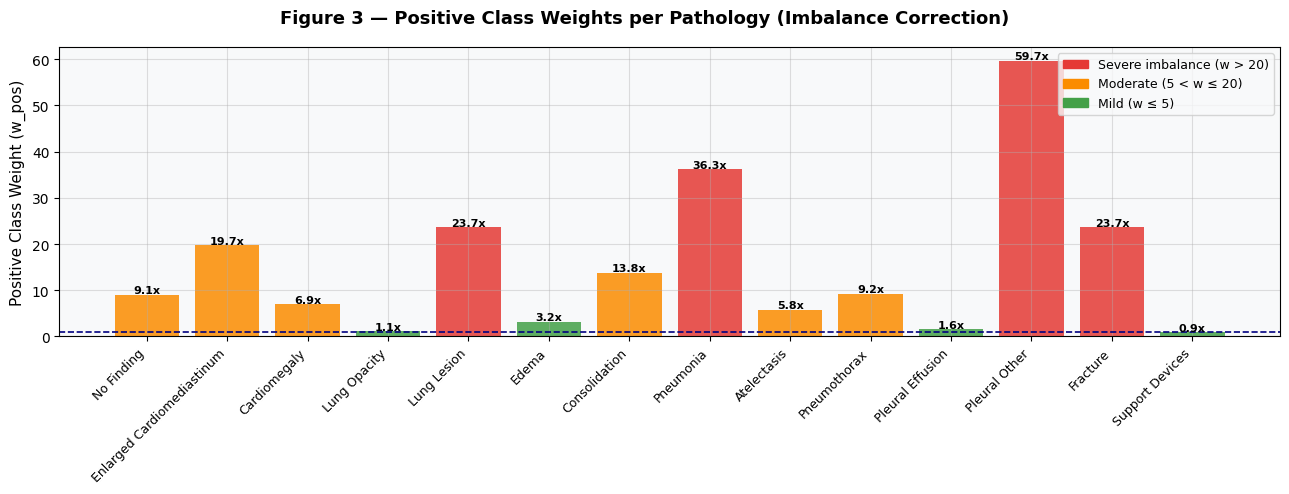

In [ ]:
# ─── Figure 3: Class weight visualisation ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Figure 3 — Positive Class Weights per Pathology (Imbalance Correction)',
             fontsize=13, fontweight='bold')

labels  = list(class_weights.keys())
weights = list(class_weights.values())
colors  = ['#E53935' if w > 20 else '#FB8C00' if w > 5 else '#43A047'
           for w in weights]

bars = ax.bar(labels, weights, color=colors, alpha=0.85)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Positive Class Weight (w_pos)', fontsize=11)
ax.axhline(1.0, color='navy', linestyle='--', linewidth=1.2, label='Balanced (w=1)')

for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{w:.1f}x', ha='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [
    Patch(color='#E53935', label='Severe imbalance (w > 20)'),
    Patch(color='#FB8C00', label='Moderate (5 < w ≤ 20)'),
    Patch(color='#43A047', label='Mild (w ≤ 5)'),
]
ax.legend(handles=legend_els, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb2_03_class_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Image Preprocessing Functions

All images undergo the following transformations before being fed to the model:

1. **Read** as grayscale (CheXpert images are single-channel)
2. **Resize** to 224×224 using bilinear interpolation
3. **Stack** grayscale channel 3× to create a pseudo-RGB image (required by ImageNet weights)
4. **Normalize** pixel values from `[0, 255]` to `[0.0, 1.0]`

Normalization to `[0, 1]` is used instead of ImageNet mean/std subtraction because chest X-rays have a fundamentally different pixel distribution than natural images.

In [ ]:
def preprocess_image(path: str, img_size: int = IMG_SIZE) -> np.ndarray:
    """
    Load, resize, and normalise a single CheXpert X-ray image.

    Parameters
    ----------
    path     : str   — absolute path to the JPEG image file
    img_size : int   — target width and height in pixels (default: 224)

    Returns
    -------
    np.ndarray of shape (img_size, img_size, 3), dtype float32, values in [0, 1]
    Returns None if the file cannot be read.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    img = np.stack([img, img, img], axis=-1)
    img = img.astype(np.float32) / 255.0
    return img


# ─── Smoke-test: find first readable image ────────────────────────────────
sample_img = None
for path in train_df['full_path']:
    candidate = preprocess_image(path)
    if candidate is not None:
        sample_img = candidate
        print(f'Tested path   : {path}')
        break

assert sample_img is not None, 'No readable images found in train_df'
print(f'Output shape  : {sample_img.shape}')
print(f'Dtype         : {sample_img.dtype}')
print(f'Pixel range   : [{sample_img.min():.4f}, {sample_img.max():.4f}]')
assert sample_img.shape == (IMG_SIZE, IMG_SIZE, 3)
assert sample_img.dtype == np.float32
assert 0.0 <= sample_img.min() and sample_img.max() <= 1.0
print('All assertions passed.')

Tested path   : /content/drive/MyDrive/CheXpert_Project/data/train/patient02119/study4/view1_frontal.jpg
Output shape  : (224, 224, 3)
Dtype         : float32
Pixel range   : [0.0000, 1.0000]
All assertions passed.


---
## 9. Data Augmentation Strategy

Augmentation is applied **only to the training set** to increase effective dataset size and improve generalisation. The transformations are chosen to be **clinically plausible** — augmentations that could occur in real-world imaging conditions:

| Augmentation | Range | Justification |
|---|---|---|
| Horizontal flip | p=0.5 | Situs inversus is rare; bilateral structures appear in both orientations |
| Rotation | ±10° | Patient positioning variability |
| Zoom | ±10% | Variable detector-to-patient distance |
| Brightness | ±15% | kVp and mAs exposure variability |

> **Not applied:** vertical flip (unphysiological), extreme shear, colour jitter (grayscale images).

In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomBrightness
from tensorflow.keras import Sequential

data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(factor=0.06),         # ±10° / 180° ≈ 0.056 radians fraction
    RandomZoom(height_factor=(-0.1, 0.1)),
    RandomBrightness(factor=0.15),
], name='data_augmentation')

print('Augmentation pipeline:')
data_augmentation.summary()

Augmentation pipeline:


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

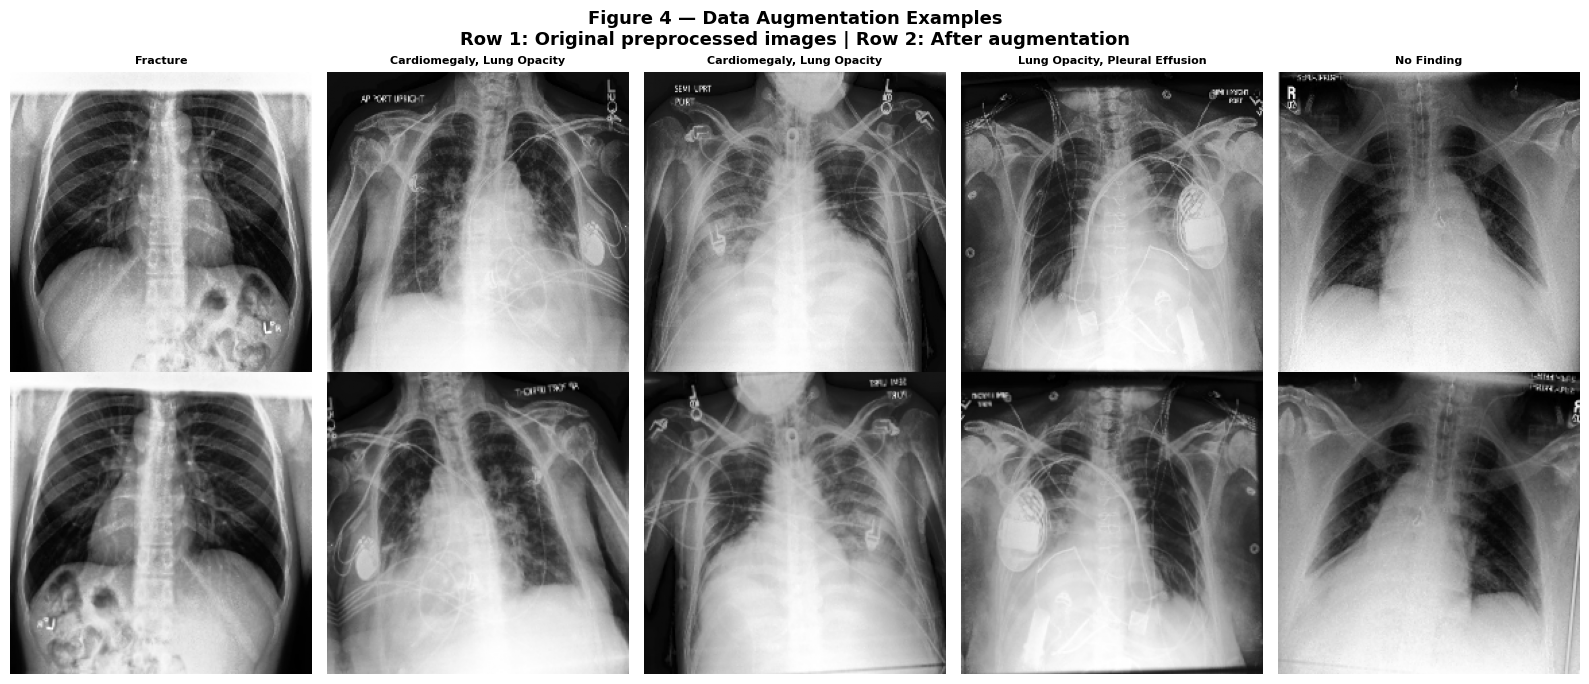

In [ ]:
# ─── Figure 4: Augmentation examples ────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Figure 4 — Data Augmentation Examples\n'
             'Row 1: Original preprocessed images | Row 2: After augmentation',
             fontsize=13, fontweight='bold')

# Find 5 readable images
readable_rows = []
for _, row in train_df.sample(frac=1, random_state=99).iterrows():
    img = preprocess_image(row['full_path'])
    if img is not None:
        readable_rows.append((row, img))
    if len(readable_rows) == 5:
        break

def safe_augment(img):
    """Augmentation: horizontal flip + small rotation only."""
    import cv2, numpy as np
    # Horizontal flip
    aug = img[:, ::-1, :].copy()
    # Small rotation ±8 degrees
    h, w = aug.shape[:2]
    angle = np.random.uniform(-8, 8)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    ch0 = cv2.warpAffine(aug[:,:,0], M, (w,h),
                         flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REFLECT)
    aug = np.stack([ch0, ch0, ch0], axis=-1)
    aug = np.clip(aug, 0.0, 1.0)
    return aug

for col_idx, (row, img) in enumerate(readable_rows):
    # Row 1: Original
    axes[0, col_idx].imshow(img[:, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, col_idx].axis('off')
    active = [c for c in LABEL_COLS if row[c] == 1.0]
    title  = ', '.join(active[:2]) if active else 'No Finding'
    axes[0, col_idx].set_title(title, fontsize=8, fontweight='bold')

    # Row 2: Augmented
    aug_img = safe_augment(img)
    axes[1, col_idx].imshow(aug_img[:, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, col_idx].axis('off')

for ax, lbl in zip(axes[:, 0], ['Original', 'Augmented']):
    ax.set_ylabel(lbl, fontsize=11, fontweight='bold',
                  rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb2_04_augmentation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Building the tf.data Pipeline

An efficient `tf.data.Dataset` pipeline is constructed for each split. The pipeline:
- Reads images on-the-fly from disk (avoids loading all 11 GB into RAM)
- Applies preprocessing in parallel using `AUTOTUNE` workers
- Caches decoded images in memory after the first epoch
- Applies augmentation only on the training split
- Prefetches batches to keep the GPU busy

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_tf(path: tf.Tensor, label: tf.Tensor):
    """
    TensorFlow-native image loading function for use inside tf.data.Dataset.
    Reads JPEG, decodes to grayscale, resizes, stacks to 3 channels, normalises.
    """
    raw   = tf.io.read_file(path)
    img   = tf.image.decode_jpeg(raw, channels=1)                 # (H, W, 1)
    img   = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])             # (224, 224, 1)
    img   = tf.repeat(img, repeats=3, axis=-1)                    # (224, 224, 3)
    img   = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment_tf(img: tf.Tensor, label: tf.Tensor):
    """Apply the Keras augmentation pipeline to a single (image, label) pair."""
    img = data_augmentation(tf.expand_dims(img, 0), training=True)[0]
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def build_dataset(df, label_cols, augment=False,
                  batch_size=BATCH_SIZE, shuffle=False):
    """
    Build a tf.data.Dataset from a metadata DataFrame.

    Parameters
    ----------
    df          : pd.DataFrame with 'full_path' and label columns
    label_cols  : list of label column names
    augment     : bool — apply augmentation (training only)
    batch_size  : int
    shuffle     : bool — shuffle before batching (training only)

    Returns
    -------
    tf.data.Dataset yielding (image_batch, label_batch) tuples
    """
    paths  = df['full_path'].values
    labels = df[label_cols].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(10_000, len(df)), seed=SEED)

    ds = ds.map(load_and_preprocess_tf, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(augment_tf, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# ─── Build datasets ──────────────────────────────────────────────────────────
train_ds = build_dataset(train_df, LABEL_COLS, augment=True,  shuffle=True)
val_ds   = build_dataset(val_df,   LABEL_COLS, augment=False, shuffle=False)
test_ds  = build_dataset(test_df,  LABEL_COLS, augment=False, shuffle=False)
gold_ds  = build_dataset(valid_clean, LABEL_COLS, augment=False, shuffle=False)

print('Datasets built:')
print(f'  train_ds : {len(train_df):,} samples → {len(train_df)//BATCH_SIZE:,} batches/epoch')
print(f'  val_ds   : {len(val_df):,} samples')
print(f'  test_ds  : {len(test_df):,} samples')
print(f'  gold_ds  : {len(valid_clean):,} samples (official CheXpert val)')

Datasets built:
  train_ds : 83,852 samples → 2,620 batches/epoch
  val_ds   : 10,482 samples
  test_ds  : 10,482 samples
  gold_ds  : 234 samples (official CheXpert val)


---
## 11. Pipeline Verification

A single batch is fetched from each dataset to verify that shapes, dtypes, and value ranges are correct before any model is trained.

In [ ]:
# ─── Fetch one batch from each split and print statistics ───────────────────
print('Batch verification:\n')
for name, ds in [('train_ds', train_ds), ('val_ds', val_ds),
                  ('test_ds', test_ds),   ('gold_ds', gold_ds)]:
    imgs, lbls = next(iter(ds))
    print(f'  [{name}]')
    print(f'    Image batch shape : {imgs.shape}')
    print(f'    Label batch shape : {lbls.shape}')
    print(f'    Image dtype       : {imgs.dtype}')
    print(f'    Pixel min/max     : [{imgs.numpy().min():.4f}, {imgs.numpy().max():.4f}]')
    print(f'    Label unique vals : {sorted(np.unique(lbls.numpy()).tolist())}')
    print()

Batch verification:

  [train_ds]
    Image batch shape : (32, 224, 224, 3)
    Label batch shape : (32, 14)
    Image dtype       : <dtype: 'float32'>
    Pixel min/max     : [0.0000, 1.0000]
    Label unique vals : [0.0, 1.0]

  [val_ds]
    Image batch shape : (32, 224, 224, 3)
    Label batch shape : (32, 14)
    Image dtype       : <dtype: 'float32'>
    Pixel min/max     : [0.0000, 1.0000]
    Label unique vals : [0.0, 1.0]

  [test_ds]
    Image batch shape : (32, 224, 224, 3)
    Label batch shape : (32, 14)
    Image dtype       : <dtype: 'float32'>
    Pixel min/max     : [0.0000, 1.0000]
    Label unique vals : [0.0, 1.0]

  [gold_ds]
    Image batch shape : (32, 224, 224, 3)
    Label batch shape : (32, 14)
    Image dtype       : <dtype: 'float32'>
    Pixel min/max     : [0.0000, 1.0000]
    Label unique vals : [0.0, 1.0]



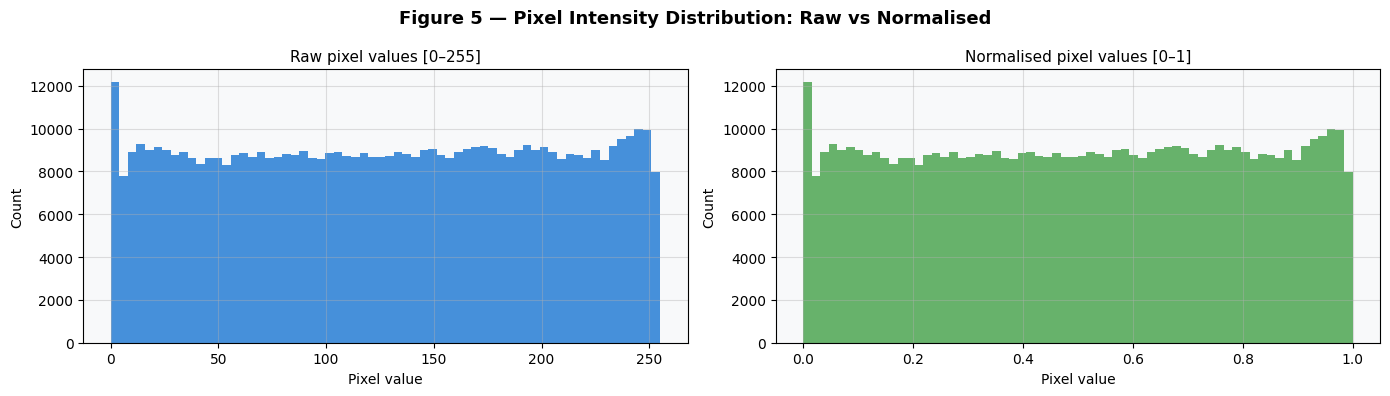

In [ ]:
# ─── Figure 5: Pixel intensity distribution pre vs post preprocessing ────────
raw_pixels, clean_pixels = [], []

sampled = 0
for path in train_df['full_path'].sample(frac=1, random_state=7):
    raw = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if raw is None:
        continue
    raw_pixels.extend(raw.flatten().tolist())
    clean_pixels.extend((raw / 255.0).flatten().tolist())
    sampled += 1
    if sampled == 5:
        break

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Figure 5 — Pixel Intensity Distribution: Raw vs Normalised',
             fontsize=13, fontweight='bold')

axes[0].hist(raw_pixels,   bins=64, color='#1976D2', alpha=0.8, edgecolor='none')
axes[0].set_title('Raw pixel values [0–255]', fontsize=11)
axes[0].set_xlabel('Pixel value')
axes[0].set_ylabel('Count')

axes[1].hist(clean_pixels, bins=64, color='#43A047', alpha=0.8, edgecolor='none')
axes[1].set_title('Normalised pixel values [0–1]', fontsize=11)
axes[1].set_xlabel('Pixel value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb2_05_pixel_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Save Processed Metadata & Pipeline Config

The cleaned metadata DataFrames and class weights are saved to `/content/drive/MyDrive/CheXpert_Project/outputs/` so that subsequent training notebooks can load them directly without re-running the preprocessing steps.

In [ ]:
import json

# ─── Save split CSVs ────────────────────────────────────────────────────────
train_df.to_csv(os.path.join(OUT_DIR, 'train_split.csv'), index=False)
val_df.to_csv(  os.path.join(OUT_DIR, 'val_split.csv'),   index=False)
test_df.to_csv( os.path.join(OUT_DIR, 'test_split.csv'),  index=False)
valid_clean.to_csv(os.path.join(OUT_DIR, 'gold_split.csv'), index=False)

# ─── Save class weights ─────────────────────────────────────────────────────
with open(os.path.join(OUT_DIR, 'class_weights.json'), 'w') as f:
    json.dump(class_weights, f, indent=2)

# ─── Save pipeline config ───────────────────────────────────────────────────
config = {
    'img_size':    IMG_SIZE,
    'channels':    CHANNELS,
    'batch_size':  BATCH_SIZE,
    'num_classes': NUM_CLASSES,
    'label_cols':  LABEL_COLS,
    'seed':        SEED,
    'base_path':   BASE_PATH,
    'uncertainty_strategy': 'U-Zeros',
    'view_filter': 'Frontal only',
    'split': {
        'train': len(train_df),
        'val':   len(val_df),
        'test':  len(test_df),
        'gold':  len(valid_clean)
    }
}
with open(os.path.join(OUT_DIR, 'pipeline_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

# ─── List saved files ───────────────────────────────────────────────────────
print('Files saved to /content/drive/MyDrive/CheXpert_Project/outputs/:')
for fname in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
    print(f'  {fname:<35}  {size:>8.1f} KB')

Files saved to /content/drive/MyDrive/CheXpert_Project/outputs/:
  class_weights.json                        0.4 KB
  fig6_sample_xrays.png                  2605.4 KB
  fig_nb2_01_uzeros_effect.png            108.6 KB
  fig_nb2_02_split_consistency.png         98.7 KB
  fig_nb2_03_class_weights.png            124.7 KB
  fig_nb2_04_augmentation.png            1313.5 KB
  fig_nb2_05_pixel_distribution.png        51.4 KB
  gold_split.csv                           52.5 KB
  pipeline_config.json                      0.6 KB
  test_split.csv                         2345.5 KB
  train_split.csv                       18762.5 KB
  val_split.csv                          2345.6 KB


---
## 13. Preprocessing Summary

This notebook established the complete data pipeline that will be used across all three model training notebooks.

In [ ]:
print('=' * 65)
print('  NOTEBOOK 2 — PREPROCESSING PIPELINE SUMMARY')
print('=' * 65)
print()
print('  INPUT')
print(f'    Raw training studies         : 223,414')
print(f'    After frontal filter         : {len(train_clean):,}')
print()
print('  LABEL HANDLING')
print(f'    Strategy                     : U-Zeros')
print(f'    NaN and -1.0 mapped to       : 0.0 (negative)')
print(f'    Final label dtype            : float32, values in {{0.0, 1.0}}')
print()
print('  IMAGE PIPELINE')
print(f'    Input format                 : JPEG grayscale')
print(f'    Resize                       : {IMG_SIZE}×{IMG_SIZE} (bilinear)')
print(f'    Channels                     : 3 (grayscale stacked)')
print(f'    Normalisation                : [0, 255] → [0.0, 1.0]')
print()
print('  AUGMENTATION (train only)')
print(f'    Horizontal flip              : p = 0.50')
print(f'    Rotation                     : ± 10°')
print(f'    Zoom                         : ± 10%')
print(f'    Brightness                   : ± 15%')
print()
print('  SPLITS')
print(f'    Training set                 : {len(train_df):,} studies (80%)')
print(f'    Validation set               : {len(val_df):,} studies (10%)')
print(f'    Test set                     : {len(test_df):,} studies (10%)')
print(f'    Gold-standard (CheXpert val) : {len(valid_clean):,} studies')
print()
print('  SAVED ARTEFACTS (/content/drive/MyDrive/CheXpert_Project/outputs/)')
print('    train_split.csv | val_split.csv | test_split.csv | gold_split.csv')
print('    class_weights.json | pipeline_config.json')
print('=' * 65)

  NOTEBOOK 2 — PREPROCESSING PIPELINE SUMMARY

  INPUT
    Raw training studies         : 223,414
    After frontal filter         : 104,816

  LABEL HANDLING
    Strategy                     : U-Zeros
    NaN and -1.0 mapped to       : 0.0 (negative)
    Final label dtype            : float32, values in {0.0, 1.0}

  IMAGE PIPELINE
    Input format                 : JPEG grayscale
    Resize                       : 224×224 (bilinear)
    Channels                     : 3 (grayscale stacked)
    Normalisation                : [0, 255] → [0.0, 1.0]

  AUGMENTATION (train only)
    Horizontal flip              : p = 0.50
    Rotation                     : ± 10°
    Zoom                         : ± 10%
    Brightness                   : ± 15%

  SPLITS
    Training set                 : 83,852 studies (80%)
    Validation set               : 10,482 studies (10%)
    Test set                     : 10,482 studies (10%)
    Gold-standard (CheXpert val) : 234 studies

  SAVED ARTEFACTS (/conte

---

## References

1. Irvin, J., et al. (2019). **CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison.** *AAAI.* https://doi.org/10.1609/aaai.v33i01.3301590

2. Rajpurkar, P., et al. (2017). **CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning.** *arXiv:1711.05225.*

3. He, K., et al. (2016). **Deep Residual Learning for Image Recognition.** *CVPR.* https://doi.org/10.1109/CVPR.2016.90

4. Huang, G., et al. (2017). **Densely Connected Convolutional Networks.** *CVPR.* https://doi.org/10.1109/CVPR.2017.243